# Supplementary Figure 9: Vero Section B (Microscopy `.lsm`)

**Description:**
This notebook reproduces Section B from `figure_2.ipynb` for Vero cells, using confocal microscopy `.lsm` files instead of flow cytometry `.fcs`.

Workflow:

- Load and parse VERO `.lsm` files from one or more folders

- Compute phasor coordinates and infer conditions from filename (`Control`, `MβCD`)

- Load MLV `.lsm` references and estimate Lo/Ld anchors from condition-wise average centers

- Fit 2-component fractions (`L_o`, `L_d`)

- Generate full and zoomed phasor contour plots

- Plot normalized `Fraction_Lo` distributions

## 1. Import Dependencies

This section imports all required libraries for loading data, phasor computation, and plotting.

In [1]:
import os
import re

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from phasorpy.component import phasor_component_fit
from phasorpy.filter import phasor_filter_median, phasor_threshold
from phasorpy.io import signal_from_lsm
from phasorpy.phasor import phasor_from_signal
from phasorpy.plot import PhasorPlot


def list_lsm_files(data_paths):
    """Return sorted .lsm files in each input folder (non-recursive)."""
    files = []
    for root_path in data_paths:
        if not os.path.exists(root_path):
            continue
        if not os.path.isdir(root_path):
            continue
        for filename in os.listdir(root_path):
            file_path = os.path.join(root_path, filename)
            if not os.path.isfile(file_path):
                continue
            if filename.lower().endswith(".lsm"):
                files.append(file_path)
    return sorted(files)


def show_close(fig):
    """Apply layout, display it, and close it."""
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def style_axes(ax, tick_size, label_size):
    """Apply shared axis styling used across phasor figures."""
    ax.set_facecolor("white")
    ax.tick_params(axis="both", which="major", labelsize=tick_size)
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)
    ax.set_title("")


def extract_vero_condition(filename):
    """Map filename text into VERO labels: MβCD or Control."""
    name = filename.lower()
    if "bmcd" in name or "bmdc" in name:
        return "MβCD"
    return "Control"


def extract_lsm_condition(filename):
    """Parse lipid filename into normalized condition labels used for MLV anchors."""
    base = re.sub(r"_\d+$", "", filename).strip()
    base = re.sub(r"(\d+)\s*Chol", r"\1%", base)
    base = re.sub(r"\s+", " ", base).strip()
    return base


def sort_vero_condition(condition):
    """Return sorting priority for VERO conditions."""
    if condition == "MβCD":
        return 0
    return 1


def normalize_harmonics(harmonics):
    """Normalize harmonic input into a list."""
    if harmonics is None:
        return [1]
    if isinstance(harmonics, int):
        return [harmonics]
    return harmonics


def _split_harmonics(real, imag, harmonics):
    """Return lists of harmonic arrays independent of phasor output shape."""
    if len(harmonics) == 1:
        return [np.asarray(real)], [np.asarray(imag)]

    real_array = np.asarray(real)
    imag_array = np.asarray(imag)

    if real_array.shape[0] == len(harmonics):
        real_harmonics = [real_array[i] for i in range(len(harmonics))]
        imag_harmonics = [imag_array[i] for i in range(len(harmonics))]
    elif real_array.shape[-1] == len(harmonics):
        real_harmonics = [np.take(real_array, i, axis=-1) for i in range(len(harmonics))]
        imag_harmonics = [np.take(imag_array, i, axis=-1) for i in range(len(harmonics))]
    else:
        raise ValueError(
            f"Unexpected harmonic shape: real={real_array.shape}, imag={imag_array.shape}"
        )

    return real_harmonics, imag_harmonics


def resolve_mask_paths(data_paths, mask_paths=None):
    """Resolve mask roots, defaulting each data path to a `mask` subfolder."""
    if not data_paths:
        return None

    if mask_paths is None:
        return [os.path.join(data_root, "mask") for data_root in data_paths]

    if len(data_paths) != len(mask_paths):
        raise ValueError("data_paths and mask_paths must have the same length.")

    return mask_paths


def get_mask_file_for_lsm(file_path, data_paths, mask_paths):
    """Return matching mask path for an LSM file using aligned data/mask roots.
    
    Supports two mask directory structures:
    1. Root mask folder (e.g., <data_path>/mask/mask_<filename>.png)
    2. Local mask folder at same level as LSM (e.g., <lsm_dir>/mask/mask_<filename>.png)
    """
    if not data_paths or not mask_paths:
        return None

    file_abs = os.path.abspath(file_path)
    file_dir = os.path.dirname(file_abs)
    base_filename = os.path.splitext(os.path.basename(file_path))[0]
    
    # First, try local mask folder at same level as LSM file
    local_mask_folder = os.path.join(file_dir, "mask")
    local_candidate = os.path.join(local_mask_folder, f"mask_{base_filename}.png")
    if os.path.isfile(local_candidate):
        return local_candidate

    # Fall back to root mask folder specified in mask_paths
    for data_root, mask_root in zip(data_paths, mask_paths):
        data_root_abs = os.path.abspath(data_root)
        try:
            is_under_root = os.path.commonpath([file_abs, data_root_abs]) == data_root_abs
        except ValueError:
            is_under_root = False

        if not is_under_root:
            continue

        relative_dir = os.path.relpath(os.path.dirname(file_path), data_root_abs)

        candidates = []
        if relative_dir != ".":
            candidates.append(
                os.path.join(mask_root, relative_dir, f"mask_{base_filename}.png")
            )
        candidates.append(os.path.join(mask_root, f"mask_{base_filename}.png"))

        for candidate in candidates:
            if os.path.isfile(candidate):
                return candidate

    return None


def load_mask_for_lsm(file_path, data_paths, mask_paths, target_shape):
    """Load a PNG mask for an LSM file and adapt size to target array shape."""
    if target_shape is None or len(target_shape) < 2:
        return None

    mask_file = get_mask_file_for_lsm(file_path, data_paths, mask_paths)
    if mask_file is None:
        return None

    mask_img = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    if mask_img is None:
        return None

    target_hw = (target_shape[0], target_shape[1])
    if mask_img.shape != target_hw:
        mask_img = cv2.resize(
            mask_img, (target_hw[1], target_hw[0]), interpolation=cv2.INTER_NEAREST
        )

    return mask_img > 0


def apply_mask_to_arrays(mean, real, imag, mask):
    """Apply mask to phasor arrays, setting masked values to NaN."""
    if mask is None:
        return mean, real, imag

    keep_mask = mask.astype(bool)

    mean_masked = np.asarray(mean).copy()
    mean_masked[~keep_mask] = np.nan

    def _mask_value(value):
        value_masked = np.asarray(value).copy()
        value_masked[~keep_mask] = np.nan
        return value_masked

    if isinstance(real, list):
        real_masked = [_mask_value(r) for r in real]
    else:
        real_masked = _mask_value(real)

    if isinstance(imag, list):
        imag_masked = [_mask_value(i) for i in imag]
    else:
        imag_masked = _mask_value(imag)

    return mean_masked, real_masked, imag_masked


def get_phasor_dataframe_from_lsm(
    lsm_file_list,
    condition_extractor=None,
    harmonics=None,
    axis=0,
    mean_min=5,
    data_paths=None,
    mask_paths=None,
):
    """Compute phasor features from .lsm files and return a tidy DataFrame."""
    harmonics = normalize_harmonics(harmonics)
    resolved_mask_paths = resolve_mask_paths(data_paths, mask_paths)

    mean_data = []
    real_data = {h: [] for h in harmonics}
    imag_data = {h: [] for h in harmonics}
    condition_labels = []
    source_files = []

    for file_path in lsm_file_list:
        filename = os.path.splitext(os.path.basename(file_path))[0]
        condition = condition_extractor(filename) if condition_extractor else filename

        signal = signal_from_lsm(file_path)
        if len(harmonics) == 1:
            mean, real, imag = phasor_from_signal(
                signal, harmonic=harmonics[0], axis=axis
            )
        else:
            mean, real, imag = phasor_from_signal(
                signal, harmonic=harmonics, axis=axis
            )

        mean, real, imag = phasor_filter_median(mean, real, imag, size=3, repeat=3)
        mean, real, imag = phasor_threshold(mean, real, imag, mean_min=mean_min)

        real_harmonics, imag_harmonics = _split_harmonics(real, imag, harmonics)

        mask = load_mask_for_lsm(
            file_path,
            data_paths,
            resolved_mask_paths,
            target_shape=np.asarray(mean).shape,
        )
        mean, real_harmonics, imag_harmonics = apply_mask_to_arrays(
            mean, real_harmonics, imag_harmonics, mask
        )

        mean_flat = np.asarray(mean).flatten()
        real_flat = [np.asarray(r).flatten() for r in real_harmonics]
        imag_flat = [np.asarray(i).flatten() for i in imag_harmonics]

        valid_mask = np.isfinite(mean_flat)
        for harmonic_index in range(len(harmonics)):
            valid_mask &= np.isfinite(real_flat[harmonic_index])
            valid_mask &= np.isfinite(imag_flat[harmonic_index])

        mean_clean = mean_flat[valid_mask]
        if len(mean_clean) == 0:
            continue

        mean_data.extend(mean_clean)
        condition_labels.extend([condition] * len(mean_clean))
        source_files.extend([filename] * len(mean_clean))

        for harmonic_index, harmonic in enumerate(harmonics):
            real_data[harmonic].extend(real_flat[harmonic_index][valid_mask])
            imag_data[harmonic].extend(imag_flat[harmonic_index][valid_mask])

    result = {
        "Mean": mean_data,
        "Condition": condition_labels,
        "SourceFile": source_files,
    }

    if len(harmonics) == 1:
        result["Real"] = real_data[harmonics[0]]
        result["Imag"] = imag_data[harmonics[0]]
    else:
        for harmonic in harmonics:
            result[f"Real_h{harmonic}"] = real_data[harmonic]
            result[f"Imag_h{harmonic}"] = imag_data[harmonic]

    return pd.DataFrame(result)


def get_average_condition_center(dataframe, condition_text):
    """Average per-file medians for a condition and return (real, imag)."""
    condition_mask = dataframe["Condition"].str.contains(
        condition_text, case=False, regex=False
    )
    condition_df = dataframe.loc[condition_mask, ["SourceFile", "Real", "Imag"]].dropna()

    if len(condition_df) == 0:
        raise ValueError(f"No MLV data found for condition containing: {condition_text}")

    file_centers = condition_df.groupby("SourceFile")[["Real", "Imag"]].median()
    center_real = file_centers["Real"].mean()
    center_imag = file_centers["Imag"].mean()
    return center_real, center_imag


def draw_component_polygon(ax, components_real, components_imag, style):
    """Draw component connectors, closing polygon for three components."""
    if len(components_real) == 3:
        real_closed = np.append(components_real, components_real[0])
        imag_closed = np.append(components_imag, components_imag[0])
        ax.plot(real_closed, imag_closed, **style)
        return
    ax.plot(components_real, components_imag, **style)


def plot_fraction_histograms(
    dataframe, columns_to_plot, output_folder, conditions=None, condition_colors=None
):
    """Plot normalized per-condition fraction histograms with mean and SD band."""
    if conditions is None:
        conditions = dataframe["Condition"].unique()

    os.makedirs(output_folder, exist_ok=True)

    for column, (x_min, x_max) in columns_to_plot.items():
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_box_aspect(1)
        bins = np.linspace(x_min, x_max, 100)
        bin_centers = (bins[:-1] + bins[1:]) / 2

        for condition in conditions:
            condition_mask = dataframe["Condition"] == condition
            selected_columns = [column] + (
                ["SourceFile"] if "SourceFile" in dataframe.columns else []
            )
            condition_df = dataframe.loc[condition_mask, selected_columns].dropna()

            if len(condition_df) == 0:
                continue

            file_ids = (
                condition_df["SourceFile"].unique()
                if "SourceFile" in condition_df.columns
                else ["all_data"]
            )
            per_file_hists = []

            for file_id in file_ids:
                if file_id == "all_data":
                    file_data = condition_df[column].to_numpy()
                else:
                    file_data = condition_df.loc[
                        condition_df["SourceFile"] == file_id, column
                    ].to_numpy()

                if len(file_data) == 0:
                    continue

                hist, _ = np.histogram(file_data, bins=bins, density=False)
                max_val = np.max(hist)
                if max_val > 0:
                    per_file_hists.append(hist / max_val)

            if len(per_file_hists) == 0:
                continue

            hist_array = np.vstack(per_file_hists)
            mean_hist = np.mean(hist_array, axis=0)
            std_hist = np.std(hist_array, axis=0)

            color = (
                condition_colors.get(condition)
                if condition_colors is not None
                else None
            )
            line = ax.plot(
                bin_centers, mean_hist, label=condition, linewidth=2, color=color
            )
            line_color = line[0].get_color()

            lower = np.clip(mean_hist - std_hist, 0, None)
            upper = np.clip(mean_hist + std_hist, 0, 1.2)
            ax.fill_between(bin_centers, lower, upper, alpha=0.25, color=line_color)

            center_of_mass = np.sum(bin_centers * mean_hist) / np.sum(mean_hist)
            if np.sum(mean_hist) > 0 and not np.isnan(center_of_mass):
                ax.axvline(
                    center_of_mass,
                    color=line_color,
                    linestyle="--",
                    linewidth=2.5,
                    alpha=0.7,
                    label=f"{condition} CM: {center_of_mass:.3f}",
                )

        xlabel_text = column.replace("_", " ")
        if xlabel_text.startswith("Fraction "):
            fraction_part = xlabel_text[len("Fraction ") :]
            xlabel_text = (
                "L$_{o}$ fraction"
                if fraction_part == "Lo"
                else f"{fraction_part} fraction"
            )

        ax.set_xlabel(xlabel_text, fontsize=20)
        ax.set_ylabel("Number of pixels + SD (normalized)", fontsize=20)
        ax.set_xlim(x_min, x_max)
        ax.legend(fontsize=14, loc="upper right")
        ax.tick_params(axis="both", which="major", labelsize=18)

        show_close(fig)

In [2]:
import tifffile


def list_image_files(data_paths):
    """Return sorted .lsm/.tif/.tiff files in each input folder (non-recursive)."""
    files = []
    for root_path in data_paths:
        if not os.path.exists(root_path):
            continue
        if not os.path.isdir(root_path):
            continue
        for filename in os.listdir(root_path):
            file_path = os.path.join(root_path, filename)
            if not os.path.isfile(file_path):
                continue
            if filename.lower().endswith((".lsm", ".tif", ".tiff")):
                files.append(file_path)
    return sorted(files)


def list_lsm_files(data_paths):
    """Backward-compatible alias for mixed .lsm/.tif/.tiff discovery."""
    return list_image_files(data_paths)


def load_signal_file(file_path):
    """Read spectral signal from .lsm/.tif/.tiff files."""
    extension = os.path.splitext(file_path)[1].lower()
    if extension == ".lsm":
        return signal_from_lsm(file_path)
    if extension in (".tif", ".tiff"):
        return tifffile.imread(file_path)
    raise ValueError(f"Unsupported file extension: {extension}")


def get_phasor_dataframe_from_lsm(
    lsm_file_list,
    condition_extractor=None,
    harmonics=None,
    axis=0,
    mean_min=5,
    data_paths=None,
    mask_paths=None,
):
    """Compute phasor features from .lsm/.tif/.tiff files and return a tidy DataFrame."""
    harmonics = normalize_harmonics(harmonics)
    resolved_mask_paths = resolve_mask_paths(data_paths, mask_paths)

    mean_data = []
    real_data = {h: [] for h in harmonics}
    imag_data = {h: [] for h in harmonics}
    condition_labels = []
    source_files = []

    for file_path in lsm_file_list:
        filename = os.path.splitext(os.path.basename(file_path))[0]
        condition = condition_extractor(filename) if condition_extractor else filename

        signal = load_signal_file(file_path)
        if len(harmonics) == 1:
            mean, real, imag = phasor_from_signal(
                signal, harmonic=harmonics[0], axis=axis
            )
        else:
            mean, real, imag = phasor_from_signal(
                signal, harmonic=harmonics, axis=axis
            )

        mean, real, imag = phasor_filter_median(mean, real, imag, size=3, repeat=3)
        mean, real, imag = phasor_threshold(mean, real, imag, mean_min=mean_min)

        real_harmonics, imag_harmonics = _split_harmonics(real, imag, harmonics)

        mask = load_mask_for_lsm(
            file_path,
            data_paths,
            resolved_mask_paths,
            target_shape=np.asarray(mean).shape,
        )
        mean, real_harmonics, imag_harmonics = apply_mask_to_arrays(
            mean, real_harmonics, imag_harmonics, mask
        )

        mean_flat = np.asarray(mean).flatten()
        real_flat = [np.asarray(r).flatten() for r in real_harmonics]
        imag_flat = [np.asarray(i).flatten() for i in imag_harmonics]

        valid_mask = np.isfinite(mean_flat)
        for harmonic_index in range(len(harmonics)):
            valid_mask &= np.isfinite(real_flat[harmonic_index])
            valid_mask &= np.isfinite(imag_flat[harmonic_index])

        mean_clean = mean_flat[valid_mask]
        if len(mean_clean) == 0:
            continue

        mean_data.extend(mean_clean)
        condition_labels.extend([condition] * len(mean_clean))
        source_files.extend([filename] * len(mean_clean))

        for harmonic_index, harmonic in enumerate(harmonics):
            real_data[harmonic].extend(real_flat[harmonic_index][valid_mask])
            imag_data[harmonic].extend(imag_flat[harmonic_index][valid_mask])

    result = {
        "Mean": mean_data,
        "Condition": condition_labels,
        "SourceFile": source_files,
    }

    if len(harmonics) == 1:
        result["Real"] = real_data[harmonics[0]]
        result["Imag"] = imag_data[harmonics[0]]
    else:
        for harmonic in harmonics:
            result[f"Real_h{harmonic}"] = real_data[harmonic]
            result[f"Imag_h{harmonic}"] = imag_data[harmonic]

    return pd.DataFrame(result)

## Load VERO `.lsm` Data

Masks are loaded automatically by setting `mask_paths = None`.
This searches for masks in two ways:
1. **Local mask folder**: `<lsm_directory>/mask/mask_<filename>.png`
2. **Root mask folder**: `<data_path>/mask/mask_<filename>.png`

To use custom mask folders, set `mask_paths` to a list with one folder per `data_paths` entry.

In [ ]:
data_paths = [
    '../data/HSI/Vero cells/Vero cells 1',
    '../data/HSI/Vero cells/Vero cells 2',
    '../data/HSI/Vero cells/Vero cells 3',
]

# If None, masks are searched by default under each data path in '<data_path>/mask'.
# You can override with one custom mask folder per data_paths entry.
mask_paths = None

output_folder_b = os.path.join("Supp_Figure_3", "Figure_3b")
os.makedirs(output_folder_b, exist_ok=True)

image_files = list_lsm_files(data_paths)
print(f"Total image files (.lsm/.tif/.tiff) detected: {len(image_files)}")

vero_phasor_dataframe = get_phasor_dataframe_from_lsm(
    image_files,
    condition_extractor=extract_vero_condition,
    harmonics=[1],
    axis=0,
    mean_min=5,
    data_paths=data_paths,
    mask_paths=mask_paths,
)

if len(vero_phasor_dataframe) == 0:
    raise ValueError("No valid phasor data extracted. Check paths, masks, and signal quality.")

unique_conditions_b = sorted(
    vero_phasor_dataframe["Condition"].unique(),
    key=sort_vero_condition,
)

print("Conditions found:", unique_conditions_b)
print(vero_phasor_dataframe.groupby("Condition").size())

Total image files (.lsm/.tif/.tiff) detected: 60
Conditions found: ['MβCD', 'Control']
Condition
Control    2144625
MβCD       1395285
dtype: int64


## Component Analysis (Lo / Ld from MLV `.lsm`)

This section loads MLV `.lsm` references, computes condition-wise average centers across files, and uses:

- `Lo` from `DPPC 33%`

- `Ld` from `DOPC 0%`

In [ ]:
mlv_data_paths = [
    '../data/HSI/MVLs/MLVs 1',
    '../data/HSI/MVLs/MLVs 2',
]

# Optional override for MLV masks. If None, default is <data_path>/mask for each entry.
mlv_mask_paths = None

mlv_image_files = list_lsm_files(mlv_data_paths)
print(f"Total MLV image files (.lsm/.tif/.tiff) detected: {len(mlv_image_files)}")

mlv_phasor_dataframe = get_phasor_dataframe_from_lsm(
    mlv_image_files,
    condition_extractor=extract_lsm_condition,
    harmonics=[1],
    axis=0,
    mean_min=3,
    data_paths=mlv_data_paths,
    mask_paths=mlv_mask_paths,
)

if len(mlv_phasor_dataframe) == 0:
    raise ValueError("No valid MLV phasor data extracted. Check MLV paths, masks, and labels.")

# Corrected mapping: Lo from DPPC 33%, Ld from DOPC 0%.
lo_real, lo_imag = get_average_condition_center(mlv_phasor_dataframe, "DPPC 33%")
ld_real, ld_imag = get_average_condition_center(mlv_phasor_dataframe, "DOPC 0%")

components_real_b = np.array([lo_real, ld_real])
components_imag_b = np.array([lo_imag, ld_imag])

fractions_b = phasor_component_fit(
    vero_phasor_dataframe["Mean"].to_numpy(),
    vero_phasor_dataframe["Real"].to_numpy(),
    vero_phasor_dataframe["Imag"].to_numpy(),
    components_real_b,
    components_imag_b,
 )

vero_phasor_dataframe[["Fraction_Lo", "Fraction_Ld"]] = fractions_b.T
print(f"Lo center (DPPC 33%): ({lo_real:.4f}, {lo_imag:.4f})")
print(f"Ld center (DOPC 0%): ({ld_real:.4f}, {ld_imag:.4f})")
vero_phasor_dataframe.head()

Total MLV image files (.lsm/.tif/.tiff) detected: 84
Lo center (DPPC 33%): (0.5158, 0.5779)
Ld center (DOPC 0%): (-0.0240, 0.6892)


,Mean,Condition,SourceFile,Real,Imag,Fraction_Lo,Fraction_Ld
0,6.785714,MβCD,vero + BMCD Laurdan + 1,0.127558,0.624070,0.288640,0.696004
1,5.821429,MβCD,vero + BMCD Laurdan + 1,0.127558,0.655669,0.281287,0.717669
2,5.678571,MβCD,vero + BMCD Laurdan + 1,0.114171,0.655669,0.257129,0.740576
3,5.428571,MβCD,vero + BMCD Laurdan + 1,0.084974,0.655669,0.204445,0.790534
4,5.071429,MβCD,vero + BMCD Laurdan + 1,0.084974,0.642039,0.207616,0.781189


## VERO Overview Phasor Plot

Contour map with condition medians and Lo/Ld component line.

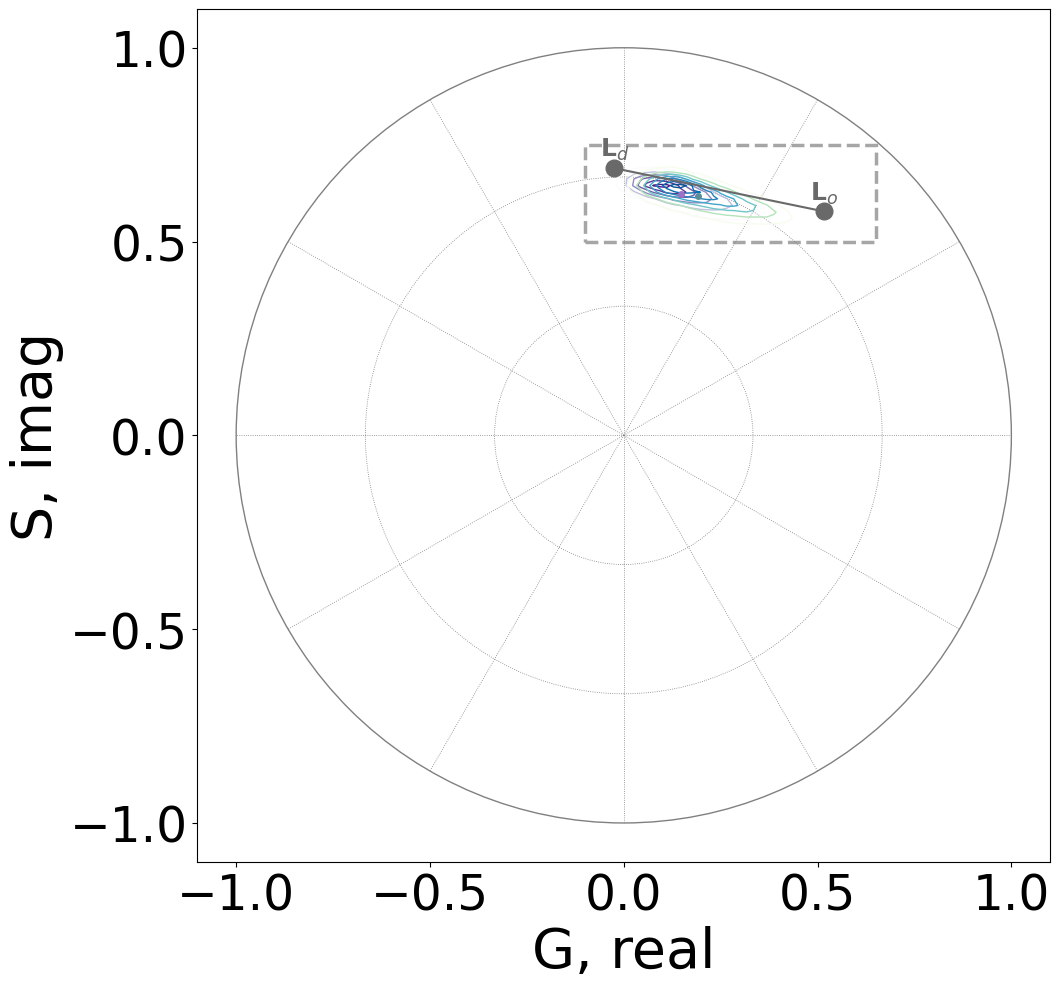

In [5]:
condition_color_mapping_b = {
    "MβCD": {"cmap": "Purples", "color": "#9D71C3"},
    "Control": {"cmap": "GnBu", "color": "#588E98"},
}

fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=35, label_size=40)
phasor_plot = PhasorPlot(allquadrants=True, title="", ax=ax, pad=0.1)

for condition in unique_conditions_b:
    condition_data = vero_phasor_dataframe[vero_phasor_dataframe["Condition"] == condition]
    if len(condition_data) <= 10:
        continue

    real = condition_data["Real"].values
    imag = condition_data["Imag"].values
    colors_map = condition_color_mapping_b[condition]

    phasor_plot.contour(real, imag, cmap=colors_map["cmap"], linewidths=1)
    phasor_plot.plot(
        np.nanmedian(real),
        np.nanmedian(imag),
        color=colors_map["color"],
        marker="o",
        markersize=4,
        label=condition,
        zorder=5,
    )

component_style = {
    "linestyle": "-",
    "marker": "o",
    "markersize": 12,
    "color": "dimgray",
}
draw_component_polygon(ax, components_real_b, components_imag_b, component_style)

ax.text(
    components_real_b[0],
    components_imag_b[0] + 0.015,
    "L$_{o}$",
    color="dimgray",
    fontsize=18,
    ha="center",
    va="bottom",
    fontweight="bold",
)
ax.text(
    components_real_b[1],
    components_imag_b[1] + 0.015,
    "L$_{d}$",
    color="dimgray",
    fontsize=18,
    ha="center",
    va="bottom",
    fontweight="bold",
)

zoom_xlim_b = (-0.1, 0.65)
zoom_ylim_b = (0.5, 0.75)
rect = Rectangle(
    (zoom_xlim_b[0], zoom_ylim_b[0]),
    zoom_xlim_b[1] - zoom_xlim_b[0],
    zoom_ylim_b[1] - zoom_ylim_b[0],
    linewidth=2.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
    alpha=0.7,
)
ax.add_patch(rect)

show_close(fig)

## VERO Zoom Panel

Zoomed view with condition labels and MLV-derived Lo/Ld anchors.

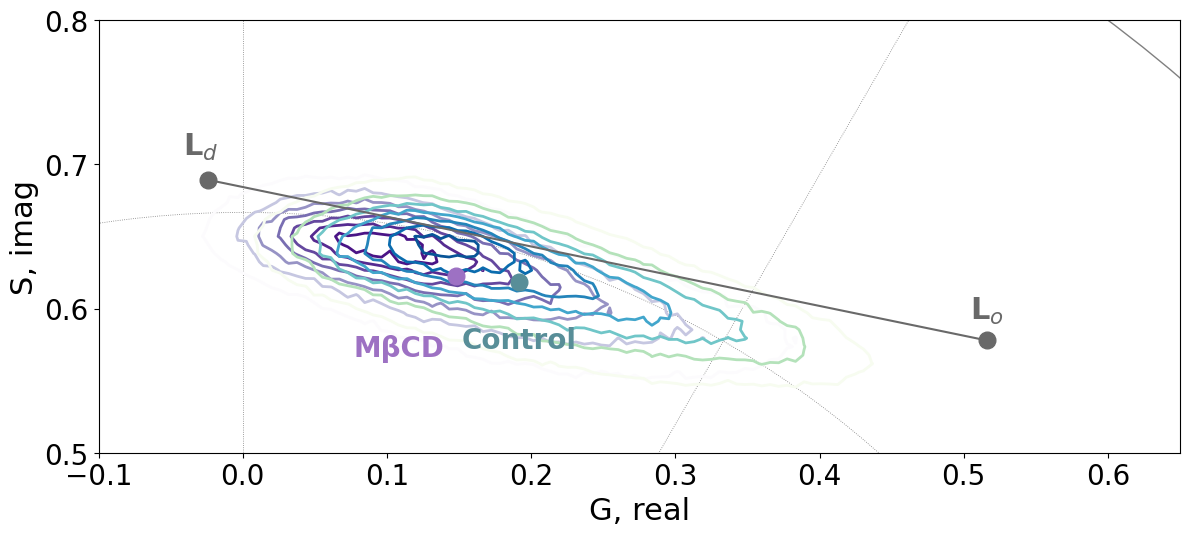

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
style_axes(ax, tick_size=20, label_size=22)
phasor_plot_zoom = PhasorPlot(
    allquadrants=True,
    title="",
    ax=ax,
    xlim=zoom_xlim_b,
    ylim=zoom_ylim_b,
)

ax.set_xticks(np.arange(-0.1, 0.7, 0.1))
ax.set_yticks(np.arange(0.5, 0.8, 0.1))

conditions_top_label = {"MβCD"}
for condition in unique_conditions_b:
    condition_data = vero_phasor_dataframe[vero_phasor_dataframe["Condition"] == condition]
    if len(condition_data) <= 10:
        continue

    real = condition_data["Real"].values
    imag = condition_data["Imag"].values
    colors_map = condition_color_mapping_b[condition]

    phasor_plot_zoom.contour(real, imag, cmap=colors_map["cmap"], linewidths=2)

    center_real = np.nanmedian(real)
    center_imag = np.nanmedian(imag)
    phasor_plot_zoom.plot(
        center_real,
        center_imag,
        color=colors_map["color"],
        marker="o",
        markersize=12,
        label=condition,
        zorder=5,
    )

    if condition in conditions_top_label:
        label_x, label_y = center_real - 0.04, center_imag - 0.06
    else:
        label_x, label_y = center_real, center_imag - 0.05

    ax.text(
        label_x,
        label_y,
        condition,
        color=colors_map["color"],
        fontsize=20,
        ha="center",
        va="bottom",
        fontweight="bold",
    )

draw_component_polygon(ax, components_real_b, components_imag_b, component_style)
ax.text(
    components_real_b[0],
    components_imag_b[0] + 0.01,
    "L$_{o}$",
    color="dimgray",
    fontsize=22,
    ha="center",
    va="bottom",
    fontweight="bold",
)
ax.text(
    components_real_b[1] - 0.005,
    components_imag_b[1] + 0.012,
    "L$_{d}$",
    color="dimgray",
    fontsize=22,
    ha="center",
    va="bottom",
    fontweight="bold",
)

legend = ax.legend()
if legend is not None:
    legend.set_visible(False)

show_close(fig)

## Fraction Histogram (`Fraction_Lo`)

Histogram comparison for `MβCD` and `Control`.

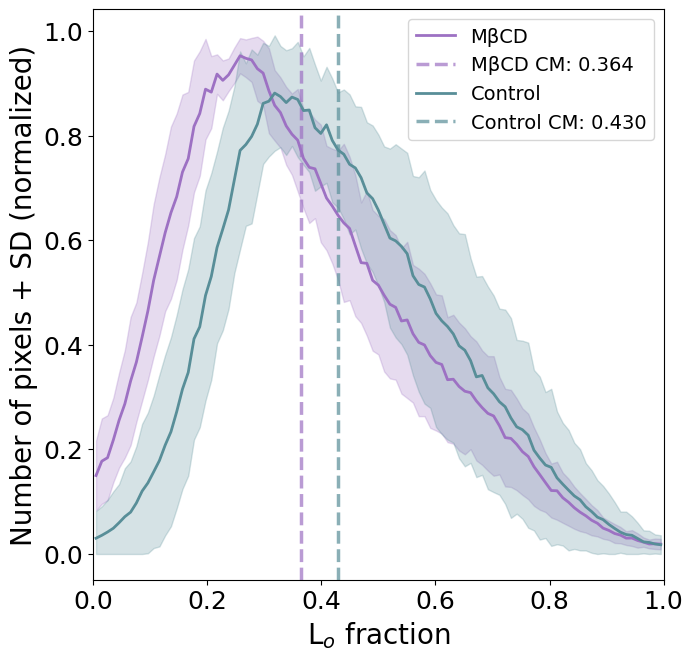

In [7]:
plot_fraction_histograms(
    vero_phasor_dataframe,
    {"Fraction_Lo": (0, 1)},
    output_folder_b,
    conditions=unique_conditions_b,
    condition_colors={
        condition: values["color"]
        for condition, values in condition_color_mapping_b.items()
    },
)